# **Assignment 2**
# **Solving 1D Poisson Equation with the Finite-Difference Method**
**Course:** Numerical Analysis For PDE's (WI3730TU)  
**Instructions:** Complete the mathematical derivations and fill in the missing code blocks marked with `# TODO`. Ensure your notebook passes a clean **Kernel -> Restart & Run All** check before submission.

## Boundary Value Problem Statement
Consider the following 1D Poisson boundary-value problem:
$$\quad -\frac{d^{2}u}{dx^{2}} = f(x), \quad x \in (0,3)$$
With the Dirichlet boundary conditions:
$$\quad u(0) = 1, \quad u(3) = 2$$
We test this system using two unique source functions:
1. $f_1(x) = 3x - 2$
2. $f_2(x) = x^2 + 3x - 2$

### **Question 1: Grid Generation & Source Function Visualization (1 p)**
Before analyzing the operator discretization matrix, generate the discrete uniform coordinates and verify your source profiles.

*Complete the code cell below to generate a uniform 1D mesh over the interval $[0,3]$ with $n=5$ sub-intervals. Compute the corresponding grid values for both $f_1(x)$ and $f_2(x)$, and plot them in a single formatted figure featuring a legend and $\LaTeX$ annotations.*

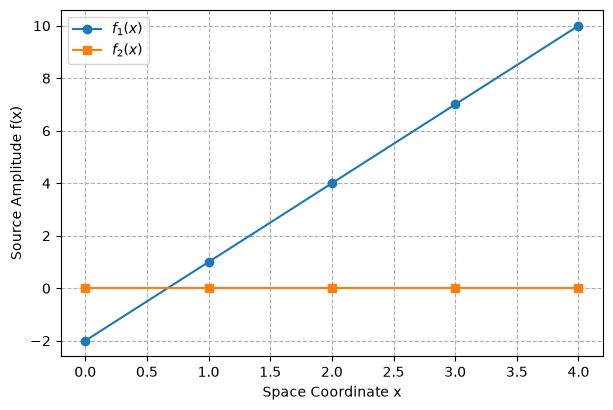

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# TODO: Step 1. Define the analytical source functions as python Callables
def f1(x):
    return 3 * x - 2

def f2(x):
    # YOUR CODE HERE: Implement the second source function
    return np.zeros_like(x) 
# -------------------------------------------------------------------------

# Step 2. Construct the grid mesh array
n = 5
L = 3.0
x_mesh = np.array([0,1,2,3,4]) # REPLACE THIS WITH np.linspace() for the actual grid

# Step 3. Generate your evaluation plot using your functions
plt.figure(figsize=(7, 4.5))
plt.plot(x_mesh, f1(x_mesh), '-o', label=r'$f_1(x)$')
plt.plot(x_mesh, f2(x_mesh), '-s', label=r'$f_2(x)$')
plt.xlabel('Space Coordinate x')
plt.ylabel('Source Amplitude f(x)')
plt.legend()
plt.grid(True, ls='--')
plt.show()

### **Question 2: Finite-Difference Approximation Theory (1 p)**
Write down the $\mathcal{O}(h^2)$ central finite-difference (FD) approximation formula for the negative second derivative operator ($-u''$), including the explicit Lagrangian remainder (truncation error) term. 

Define what domain range the arbitrary coordinate value $\xi$ belongs to.

---
*Double-click this cell to type your mathematical expression using $\LaTeX$:*


### **Question 3: Full System of Finite-Difference Equations (1 p)**
Assuming $n=5$, write down the complete system of $n+1 = 6$ finite-difference equations for the entire grid layout, explicitly including the boundary nodes $x_0$ and $x_5$. 

Provide the explicit equations for the source function $f_1(x)$ only.

---
*Double-click this cell to type your $n+1$ equations using $\LaTeX$:*


### **Question 4: Linear Algebraic System Derivation (1 p)**
Using the full system of equations from Question 3, mathematically eliminate the known Dirichlet values $u_0 = 1$ and $u_5 = 2$. 

Show how this elimination reduces the system to a compact linear algebraic problem $A\mathbf{u} = \mathbf{f}$, where $A \in \mathbb{R}^{4 \times 4}$.

---
*Double-click this cell and type the matrix $A$ and the vectors $\mathbf{f}_{1}$ and $\mathbf{f}_{2}$ of your reduced linear system using $\LaTeX$:*

### **Question 5(a): Mathematical Structure of the System Matrix (1 p)**
Before implementing the code, state the exact dimension of your internal system matrix $A$ as a function of the number of sub-intervals $n$. 

Write out the algebraic definitions for the entries of the main diagonal ($A_{i,i}$) and the sub/super-diagonals ($A_{i,i-1}$, $A_{i,i+1}$).

---
*Double-click this cell to type your mathematical definitions using $\LaTeX$:*


### **Question 5(b): Dense Matrix Assembly Function (2 p)**

*Complete the function below to assemble a dense system matrix representing the negative second derivative operator under Dirichlet conditions.*


In [13]:
def assemble_system_matrix(n, L=3.0):
    """
    Constructs the dense tridiagonal FDM matrix A.
    Inputs:
        n : Number of sub-intervals
        L : Physical domain length
    Outputs:
        A : Dense 2D numpy array of size (n-1) x (n-1)
    """
    h = L / n
    
    # -------------------------------------------------------------------------
    # TODO: Construct the dense matrix A using np.diag() configurations.
    # Ensure it automatically adapts to any integer input value of n.
    
    A = np.eye(n-1)  # REPLACE THIS WITH YOUR DENSE ASSEMBLY LOGIC
    
    # -------------------------------------------------------------------------
    return A

# Quick local test to verify structure for n=5
A_test = assemble_system_matrix(n=5)
print("Assembled Matrix A (n=5):\n", A_test)


Assembled Matrix A (n=5):
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


### **Question 6(a): Sizing of the Reduced Right-Hand-Side Vectors (1 p)**
For an arbitrary number of sub-intervals $n$ and an overall grid size of $n+1$ nodes, what is the exact vector size of your interior right-hand-side arrays $\mathbf{f}_1$ and $\mathbf{f}_2$ after boundary elimination? 

State explicitly which nodes (from $x_0$ to $x_n$) are used to evaluate the source function terms inside this reduced system and how the right-hand side vectors are modified after boundary-value elimination.

---
*Double-click this cell to type your answers:*


### **Question 6(b): Right-Hand-Side Assembly Function (2 p)**

**Your task:** complete the function below to dynamically construct the modified RHS vectors for both $f_1(x)$ and $f_2(x)$ using the eliminated Dirichlet boundary values.

----

*Complete the function below to construct a single, modified RHS vector by passing your spatial grid array and your target function handle.*

In [15]:
def assemble_rhs_vector(x_mesh, f_func, u_left=1.0, u_right=2.0):
    """=
    Constructs a generic, reduced right-hand side vector.
    Inputs:
        x_mesh   : The FULL 1D grid coordinate array (including boundaries)
        f_func  : A python function handle/callable evaluating f(x)
        u_left : Value for Dirichlet boundary conditions u(0)
        u_right : Value for Dirichlet boundary conditions u(L)
    Outputs:
        f_rhs   : Modified RHS vector applied with BC adjustments, length (len(xgrid) - 2)
    """
    n = len(x_mesh) - 1
    L = x_mesh[-1] - x_mesh[0]
    h = L / n
    
    # -------------------------------------------------------------------------
    # TODO: Step 1. Extract the interior coordinates from your passed grid array
    x_interior = np.zeros(n - 1)  # REPLACE THIS WITH YOUR INTERIOR MESH STRIDE
    
    # Evaluate the source function dynamically via its functional handle
    f_base = f_func(x_interior)
    
    # TODO: Step 2. Apply your mathematically eliminated boundary modifications
    f_rhs = f_base.copy()
    
    # YOUR BOUNDARY SHIFTING CODE HERE (Modify the first and last entries)
    
    # -------------------------------------------------------------------------
    return f_rhs

# Quick local test for sample grid [0,1,2,3,4] 
rhs1 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f1, u_left=1.0, u_right=2.0)
rhs2 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f2, u_left=1.0, u_right=2.0)
print('Assembled rhs vector for f1 source:\n',rhs1)
print('Assembled rhs vector for f2 source:\n',rhs2)


Assembled rhs vector for f1 source:
 [-2. -2. -2.]
Assembled rhs vector for f2 source:
 [0. 0. 0.]


### **Question 7: Numerical Solver Loop (2 p)**
Now that you have built modules for constructing your system matrix and RHS vetors, write a script execution block to solve the system.

**Your Task:** Complete the code cell below to generate a uniform grid over $x \in [0,3]$ for $n=5$. Call your `assemble_system_matrix` and `assemble_rhs_vector` functions to construct the linear algebra structures, apply `scipy.linalg.solve()`, and pad the boundary conditions ($u(0)=1, u(3)=2$) onto your final internal solution vectors.

In [8]:
import scipy.linalg as la

def solve_poisson_problem(n, L=3.0, u_left=1.0, u_right=2.0):
    # -------------------------------------------------------------------------
    # TODO: Step 1. Generate the true uniform grid array matching Question 1
    x_full = np.zeros(n + 1) # REPLACE THIS WITH YOUR np.linspace STRIDE
    
    # TODO: Step 2. Build system matrices by passing variables into your modules
    A_matrix = np.eye(n-1)          # REPLACE: call assemble_system_matrix
    rhs_f1 = np.zeros(n - 1)        # REPLACE: call assemble_rhs_vector for f1
    rhs_f2 = np.zeros(n - 1)        # REPLACE: call assemble_rhs_vector for f2
    # -------------------------------------------------------------------------
    
    # Direct solution execution
    u1_int = la.solve(A_matrix, rhs_f1)
    u2_int = la.solve(A_matrix, rhs_f2)
    
    # TODO: Step 3. Reconstruct full numerical solution fields including boundaries
    u1_solution = np.concatenate(([u_left], u1_int, [u_right]))
    u2_solution = np.concatenate(([u_left], u2_int, [u_right]))
    
    return x_full, u1_solution, u2_solution

# Run solution check for baseline parameter n=5
x_mesh, u1_num, u2_num = solve_poisson_problem(n=5)
print("Numerical solver execution completed.")

Numerical solver execution completed.


### **Question 8: Analytical Comparison and Solution Visualization (1 p)**
Verify your numerical finite difference configurations by overlaying them visually with the true exact solutions.

**Your Task:** Calculate the anlytical solutions $u_1^{ex}$ and $u_2^{ex}$ of the boundary value problem for both source functions. Complete the plotting configuration below using the numerical vectors you computed in Question 7 for $n=5$ and the analytical exact values on your mesh nodes and generate a formatted comparison figure.

--- 
**Plot Guidelines:** Use solid lines for your exact solutions ($u_1^{ex}, u_2^{ex}$), and dashed lines with distinctive circular/square point markers for your discrete approximations ($u_1, u_2$). Include full grid markers, axis labels, and LaTeX legends.

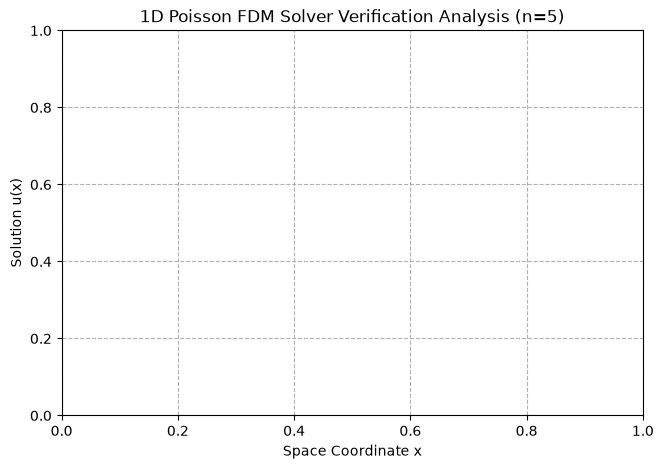

In [19]:
# TODO: Step 1. Code exact analytical solution formulas for comparison mapping
# Note: Account for non-homogeneous boundaries u(0)=1 and u(3)=2
u1_exact = np.zeros_like(x_mesh) # REPLACE: Implement exact solution formula for f1 configuration
u2_exact = np.zeros_like(x_mesh) # REPLACE: Implement exact solution formula for f2 configuration

# TODO: Step 2. Construct your overlay plot window block
plt.figure(figsize=(7.5, 5))

plt.xlabel('Space Coordinate x')
plt.ylabel('Solution u(x)')
plt.title('1D Poisson FDM Solver Verification Analysis (n=5)')
plt.grid(True, ls='--')
plt.show()

### **Question 9: Continuous vs. Discrete Eigenvalue Analysis (2 p)**
Let the analytical eigenvalues of the continuous negative second-derivative operator $-d^2/dx^2$ be denoted as $\tilde{\lambda}_i$, and the analytical eigenvalues of the corresponding discrete FDM matrix $A$ as $\lambda_i$.

**Your Task:** Using your `assemble_system_matrix` function for $n=5$, numerically calculate the matrix eigenvalues using `np.linalg.eig()`. Sort them from smallest to largest and present them side-by-side with the analytical formulas inside the LaTeX table cell below.

--- 
*Double-click this cell to modify and fill out the values in this $\LaTeX$ Table:* 

| $i$ | Continuous Operator $\tilde{\lambda}_i$ | Discrete Analytical $\lambda_i$ | Numerical Array `np.linalg.eig()` |
|---|---|---|---|
| 1 | ? | ? | ? |
| 2 | ? | ? | ? |
| 3 | ? | ? | ? |
| 4 | ? | ? | ? |

In [17]:
# TODO: Step 1. Assemble the test matrix A for n=5
A_eigen = assemble_system_matrix(n=5)

# TODO: Step 2. Compute and extract the numerical eigenvalues
raw_evals, _ = np.linalg.eig(A_eigen)
# Hint: np.linalg.eig returns an unsorted tuple (values, vectors). Extract and sort the values!

print("Your computed and sorted numerical eigenvalues:\n", raw_evals)

Your computed and sorted numerical eigenvalues:
 [1.+0.j 1.+0.j 1.+0.j 1.+0.j]


### **Question 10(a): Global Error Log-Log Convergence Plot (1 p)**
We want to observe how the overall solution error behaves asymptotically as our discrete uniform mesh grid gets progressively finer.

**Your Task:** Run the convergence nested loop cell below. It will execute your solver dynamically across an array of increasing intervals ($n = [5, 10, 20, 40, 80, 160, 320, 640]$) and plot the Root-Mean-Squared-Errors (RMSE) using a log-log scaling perspective.


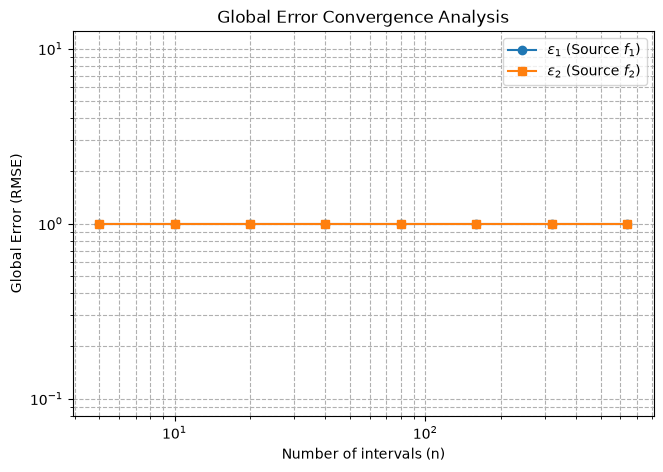

In [21]:
intervals = [5, 10, 20, 40, 80, 160, 320, 640]
errors_f1 = []
errors_f2 = []

for n in intervals:
    # Run your executive modular solver function
    x_mesh, u1_n, u2_n = solve_poisson_problem(n)
    
    # Analytical true benchmarks mapping non-homogeneous boundaries
    u1_exact = np.ones_like(x_mesh) # REPLACE: Implement exact solution formula for f1 configuration
    u2_exact = np.ones_like(x_mesh) # REPLACE: Implement exact solution formula for f2 configuration
    
    # Calculate Root Mean Squared Errors on interior nodes
    rmse_1 = np.sqrt(np.mean((u1_n[1:-1] - u1_exact[1:-1])**2))
    rmse_2 = np.sqrt(np.mean((u2_n[1:-1] - u2_exact[1:-1])**2))
    
    errors_f1.append(rmse_1)
    errors_f2.append(rmse_2)

# Generate the dynamic log-log error tracking plot
plt.figure(figsize=(7.5, 5))
plt.loglog(intervals, errors_f1, '-o', label=r'$\epsilon_1$ (Source $f_1$)')
plt.loglog(intervals, errors_f2, '-s', label=r'$\epsilon_2$ (Source $f_2$)')
plt.xlabel('Number of intervals (n)')
plt.ylabel('Global Error (RMSE)')
plt.title('Global Error Convergence Analysis')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

### **Question 10(b): Analysis of Convergence Bahavior (2 p)**

Once the graph renders, write a comprehensive analytical report explaining:

1. Why the global error $\epsilon_{1}$ (source $f_{1}$) and the global error $\epsilon_{2}$ (source $f_{2}$) behave differently.
2. Use the global error $\epsilon_{2}$ (source $f_{2}$) to prove that your scheme operates at a true quadratic rate of convergence.

---
*Double-click this cell to type your answers:*
